In [1]:
!curl "https://raw.githubusercontent.com/philipturner/swift-colab/release/latest/install_swift.sh" --output "install_swift.sh"
!bash "install_swift.sh" "5.7" #// Replace '5.7' with newest Swift version.

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8110  100  8110    0     0  39950      0 --:--:-- --:--:-- --:--:-- 39950
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  507M  100  507M    0     0  11.8M      0  0:00:42  0:00:42 --:--:-- 14.2M
Cloning into 'swift-colab'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 130 (delta 7), reused 96 (delta 7), pack-reused 0
Receiving objects: 100% (130/130), 316.49 KiB | 3.77 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Compiling Swift LLDB bindings
Compiling JupyterKernel
Adding symbolic link to JupyterKernel binary
Registering Swift Jupyter kernel
=== -------------------------------------------------------

In [1]:
// Download the text files through console commands.
// short_dataset - 667 to 2500 nm
// long_dataset - 1232 to 20000 nm
%system curl "https://omlc.org/spectra/water/data/kou93b.txt" --output "short_dataset.txt"
%system curl "https://omlc.org/spectra/water/data/hale73.txt" --output "medium_dataset.txt"
%system curl "https://omlc.org/spectra/water/data/wieliczka89.txt" --output "long_dataset.txt"
%system curl "https://omlc.org/spectra/water/data/warren95.txt" --output "ice_dataset.txt"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8259  100  8259    0     0  24653      0 --:--:-- --:--:-- --:--:-- 24727
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3505  100  3505    0     0  13377      0 --:--:-- --:--:-- --:--:-- 13377
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 62265  100 62265    0     0   138k      0 --:--:-- --:--:-- --:--:--  138k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8956  100  8956    0     0  32926      0 --:--:-- --:--:-- --:--:-- 32926


In [2]:
// - Process the text data.
// - Find log-strength countours of each wavelength in water, incorporating the 
//   inverse-square law. For example, contour at 10%, 1%, 0.1%, 0.01% strength.
// - Print out the raw values for each contour for a few wavelengths.
// - Visualize the contours using matplotlib, which supports axis bounds.

In [3]:
import Foundation
let fm = FileManager.default
let short_dataset_txt = fm.contents(atPath: "/content/short_dataset.txt")!
let medium_dataset_txt = fm.contents(atPath: "/content/medium_dataset.txt")!
let long_dataset_txt = fm.contents(atPath: "/content/long_dataset.txt")!
let ice_dataset_txt = fm.contents(atPath: "/content/ice_dataset.txt")!

// Convert to strings.
let short_data = String(data: short_dataset_txt, encoding: .ascii)!
let medium_data = String(data: medium_dataset_txt, encoding: .ascii)!
let long_data = String(data: long_dataset_txt, encoding: .ascii)!
let ice_data = String(data: ice_dataset_txt, encoding: .ascii)!

precondition(short_data.contains("\r") == false)
precondition(medium_data.contains("\r") == false)
precondition(long_data.contains("\r") == false)
precondition(ice_data.contains("\r") == false)

In [4]:
// Both show wavelength in nanometers and absorption in cm^-1. Need to convert
// both metrics to microns^(+1).
func processDataset(_ input: String) -> [SIMD2<Float>] {
  let lines = input.split(separator: "\n")
  let labelLineID = lines.firstIndex(where: { $0.contains("(nm)") })!
  let firstDataLineID = labelLineID + 1
  let dataLines = Array(lines[firstDataLineID...]).map(String.init)

  return dataLines.map { line -> SIMD2<Float> in
    var temp = ""
    var wavelength: Float?

    // Iterate through characters.
    for index in line.indices {
      let character = line[index]

      // Skip to next iteration if whitespace.
      guard character.isWhitespace == false else {
        if wavelength == nil {
          wavelength = Float(temp)
          if wavelength == nil {
            fatalError("wavelength nil")
          }
        }
        temp = ""
        continue
      }

      // Append digit/decimal to substring.
      temp.append(character)
    }
    guard var wavelength = wavelength else {
      fatalError("wavelength nil")
    }
    
    // Find absorption and adjust units.
    var absorption = Float(temp)
    guard var absorption = absorption else {
      fatalError("absorption nil")
    }

    wavelength *= 1.0 / 1000 // (1 micron) / (1000 nm)
    absorption = 1 / absorption // (cm^-1) -> (cm^+1)
    absorption *= 10_000 / 1.0 // (10,000 microns) / (1 cm)
    return [wavelength, absorption]
  }
}

let short_processed: [SIMD2<Float>] = processDataset(short_data)
let medium_processed: [SIMD2<Float>] = processDataset(medium_data).reversed()
let long_processed: [SIMD2<Float>] = processDataset(long_data)
let ice_processed: [SIMD2<Float>] = processDataset(ice_data).reversed()

// Ice varies quite a lot from liquid water, so make a second spectrum that only samples UV
let ice_shortened: [SIMD2<Float>] = ice_processed.filter { $0.x < 1 }

print(short_processed[0..<5])
print(medium_processed[0..<5])
print(long_processed[0..<5])
print(ice_processed[0..<5])

[SIMD2<Float>(2.5, 99.47185), SIMD2<Float>(2.4870002, 105.833786), SIMD2<Float>(2.4750001, 115.17793), SIMD2<Float>(2.463, 125.640594), SIMD2<Float>(2.4510002, 139.31741)]
[SIMD2<Float>(200.00002, 31.545742), SIMD2<Float>(100.00001, 14.947683), SIMD2<Float>(90.00001, 13.368984), SIMD2<Float>(80.0, 11.641443), SIMD2<Float>(70.0, 9.67118)]
[SIMD2<Float>(20.0, 4.0456347), SIMD2<Float>(19.952002, 4.0267377), SIMD2<Float>(19.908, 4.0088196), SIMD2<Float>(19.861, 3.9810505), SIMD2<Float>(19.814001, 3.953663)]
[SIMD2<Float>(611.4, 4873.2944), SIMD2<Float>(599.80005, 4723.6655), SIMD2<Float>(588.4, 4578.7544), SIMD2<Float>(577.30005, 4438.5264), SIMD2<Float>(566.4, 4302.9263)]


In [5]:
// Instructions (repeated):
// - Process the text data.
// - Find log-strength countours of each wavelength in water, incorporating the 
//   inverse-square law. For example, contour at 10%, 1%, 0.1%, 0.01% strength.
// - Print out the raw values for each contour for a few wavelengths.
// - Visualize the contours using matplotlib, which supports axis bounds.

In [6]:
// Data now in micrometers for every measurement. Find proportion of emitted
// radiation that's physically possible to capture.
//
// This is going from nanobot -> microbot, which has large receiver.
// Microbot -> nanobot signals could be more chaotic, and subject to
// interference from nearby nanobots. We try to avoid this through careful
// robot placement and calibration.
//
// Microbot receiver: 10-um cylinder encircling the capillary, looks like a
// square to the nanobot.
func receiverProportion(radius: Float) -> Float {
  guard radius >= 5 else {
    preconditionFailure("Function not valid closer than 5 microns.")
  }

  let microbotArea: Float = 10 * 10
  let totalArea = 4 * Float.pi * radius * radius
  return microbotArea / totalArea
}

func attenuation(radius: Float, absorption: Float) -> Float {
  let exponent = -(radius / absorption)
  return exp(exponent)
}

print(receiverProportion(radius: 5))
print(attenuation(radius: 5, absorption: 100))

0.3183099
0.95122945


In [7]:
// Search the data set like a massive lookup table.
// - dataset: must be in descending order
func binarySearch(dataset: [SIMD2<Float>], λ: Float) -> Float? {
  if λ > dataset.first!.x || λ < dataset.last!.x {
    return nil
  }

  // Search for lower and upper bound.
  var upperBoundID = dataset.indices.first!
  var lowerBoundID = dataset.indices.last!
  while abs(upperBoundID - lowerBoundID) > 1 {
    let middleBoundID = (upperBoundID + lowerBoundID) / 2
    let comparisonKey = dataset[middleBoundID].x
    if λ > comparisonKey {
      // Move to the left, toward larger wavelengths.
      // print("(\(upperBoundID), \(lowerBoundID)) -> (\(upperBoundID), \(middleBoundID))")
      if middleBoundID == upperBoundID {
        fatalError("Error 1: \(upperBoundID) \(lowerBoundID)")
      }
      lowerBoundID = middleBoundID
    } else {
      // Move to the right, toward smaller wavelengths.
      // print("(\(upperBoundID), \(lowerBoundID)) -> (\(middleBoundID), \(lowerBoundID))")
      if middleBoundID == lowerBoundID {
        fatalError("Error 2: \(upperBoundID) \(lowerBoundID)")
      }
      upperBoundID = middleBoundID
    }
  }
  precondition(upperBoundID + 1 == lowerBoundID, "Bounds should be one apart.")

  // Return interpolated value.
  if upperBoundID == dataset.indices.last! {
    precondition(λ == dataset.last!.x, """
      Incorrect key, lowerBoundID \(lowerBoundID) == \(dataset.indices.last!), \\
      upperBoundID \(upperBoundID), λ \(λ), dataset.last!.x \(dataset.last!.x).
      """)
    return dataset.last!.x
  }
  let upperKey = dataset[upperBoundID].x
  let lowerKey = dataset[lowerBoundID].x
  precondition(λ <= upperKey && λ >= lowerKey, """
    Incorrect key, lowerBoundID \(lowerBoundID), upperBoundID \(upperBoundID), \\
    upperKey \(upperKey), λ \(λ), lowerKey \(lowerKey).
    """)
  
  // Linearly interpolate. If closest to `lowerKey`, should be influenced more
  // by `lowerValue`.
  let upperDistance = upperKey - λ
  let lowerDistance = λ - lowerKey
  let totalDistance = upperDistance + lowerDistance
  precondition(
    upperDistance >= 0 && lowerDistance >= 0, "Invalid distances: \(upperDistance) \(lowerDistance).")
  let lowerProportion = upperDistance / totalDistance
  let upperProportion = lowerDistance / totalDistance
  precondition(
    lowerProportion <= 1 && upperProportion <= 1, "Invalid proportions.")

  let upperValue = dataset[upperBoundID].y
  let lowerValue = dataset[lowerBoundID].y
  return lowerValue * lowerProportion + upperValue * upperProportion
}

// print(binarySearch(dataset: short_processed, λ: 0.8))
// print(binarySearch(dataset: short_processed, λ: 0.9))
// print(binarySearch(dataset: short_processed, λ: 1.0))
// print(binarySearch(dataset: short_processed, λ: 1.1))
// print(binarySearch(dataset: short_processed, λ: 1.2))
// print(binarySearch(dataset: short_processed, λ: 1.3))
// print(binarySearch(dataset: short_processed, λ: 1.4))
// print(binarySearch(dataset: short_processed, λ: 1.5))
// print(binarySearch(dataset: short_processed, λ: 1.6))

In [8]:
// Instructions (repeated):
// - Process the text data.
// - Find log-strength countours of each wavelength in water, incorporating the 
//   inverse-square law. For example, contour at 10%, 1%, 0.1%, 0.01% strength.
// - Print out the raw values for each contour for a few wavelengths.
// - Visualize the contours using matplotlib, which supports axis bounds.

In [9]:
// Show contours for large dataset. When plotting, then you can show the small
// dataset.
var testPoints: [Float] = []
do {
  // Resolution of 0.1 microns
  var current: Int = 14
  while true {
    testPoints.append(Float(current) / 10)
    current += 2

    // Maximum 4.0 microns
    if current > 40 {
      break
    }
  }
}
print(testPoints)

[1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0]


In [10]:
// Finds strength at a specific radius and absorption.
func findStrength(radius: Float, absorption: Float) -> Float {
  // Multiply area coverage by attenuation.
  return receiverProportion(radius: radius) *
         attenuation(radius: radius, absorption: absorption)
}

// Linearly interpolates "y" based on value of "x".
func linearInterpolate(lower: SIMD2<Float>, upper: SIMD2<Float>, x: Float) -> Float {
  precondition(lower.x < upper.x, "lower.x \(lower.x) not < upper.x \(upper.x).")
  precondition(lower.x <= x, "lower.x \(lower.x) not < x \(x).")
  precondition(x <= upper.x, "x \(x) not < upper.x \(upper.x).")

  let weightFromUpper = x - lower.x
  let weightFromLower = upper.x - x
  let totalWeight = weightFromUpper + weightFromLower

  return (lower.y * weightFromLower + upper.y * weightFromUpper) / totalWeight
}

let testLerpLower: SIMD2<Float> = [9, 10]
let testLowerUpper: SIMD2<Float> = [13, 14]
let testLerpResult = linearInterpolate(lower: testLerpLower, upper: testLowerUpper, x: 10)
precondition(testLerpResult == 11, "Lerp produced invalid value \(testLerpResult), expected 11.")

In [11]:
let searchContourStrengths: [Float] = [0.1, 0.01, 0.001, 1e-4, 1e-5]

// absorption - distance until 1/e signal loss, in microns
func searchContours(
  absorption: Float,
  minRadius: Float = 5, // must be >= 5 microns
  maxRadius: Float = 1000
) -> [Float] {
  // Search for the range of 100 microns where each switch happens. Repeat for
  // 10 microns, 1 micron, and finally 0.1 micron.
  return searchContourStrengths.map { targetStrength -> Float in
    // Step size in 100 nanometers, NOT microns.
    var lastStep_nm = 0
    var currentStep_nm = 0
    var floors: [Int] = [] // Retain `lastStep_nm` here for validation later on.

    // Increments specified in units of 100 nanometers
    outer:
    for increment_nm in [1000 * 10, 100 * 10, 10 * 10, 1 * 10, 1] {
      floors.append(lastStep_nm)
      precondition(
        lastStep_nm == currentStep_nm, 
        "Did not reset step after last iteration. lastStep_nm \(lastStep_nm) not == currentStep_nm \(currentStep_nm).")
      currentStep_nm = lastStep_nm + increment_nm
      
      inner:
      while true {
        let currentRadius = Float(currentStep_nm) / 10
        guard currentRadius >= minRadius else {
          // Stop from exceeding lower bound
          if findStrength(radius: minRadius, absorption: absorption) < targetStrength {
            lastStep_nm = -2
            currentStep_nm = -2
            break outer
          }

          // Perform a phantom iteration.
          lastStep_nm = currentStep_nm
          currentStep_nm += increment_nm
          continue
        }

        let currentStrength = findStrength(radius: currentRadius, absorption: absorption)
        guard currentRadius < maxRadius else {
          // Stop from exceeding upper bound
          if currentStrength >= targetStrength {
            lastStep_nm = -1
            currentStep_nm = -1
            break outer
          }
          // Stepped too far forward, probably just barely reaching maxRadius.
          currentStep_nm = lastStep_nm
          break inner // Retry with higher resolution
        }
        
        // Exit early when currentStrength drops below the target strength.
        // Don't use '<=' because that would remove distances that perfectly match.
        if currentStrength < targetStrength {
          if increment_nm == 1 {
            // End of outer loop
            precondition(
              lastStep_nm + 1 == currentStep_nm, 
              "lastStep_nm \(lastStep_nm) + 1 not == \(currentStep_nm)")
            break outer
          }
          currentStep_nm = lastStep_nm
          break inner // Retry with higher resolution
        }

        // Change lastStep and currentStep after performing iteration.
        lastStep_nm = currentStep_nm
        currentStep_nm += increment_nm
      }
    }

    // Check whether it exceeded bounds. If so, both last/current should store the same error code.
    if lastStep_nm < 0 || currentStep_nm < 0 {
      precondition(lastStep_nm == currentStep_nm, "lastStep_nm \(lastStep_nm) != currentStep_nm \(currentStep_nm).")
      if lastStep_nm == -2 {
        return minRadius
      }
      if lastStep_nm == -1 {
        return maxRadius
      }
      fatalError("Invalid step.")
    }

    // Generate lowerRadius from lastStep_nm, upperRadius from currentStep_nm.
    precondition(lastStep_nm + 1 == currentStep_nm, "Steps not one apart.")
    let lowerRadius = Float(lastStep_nm) / 10
    let upperRadius = Float(currentStep_nm) / 10

    precondition(upperRadius > minRadius, "upperRadius \(upperRadius) not > minRadius \(minRadius).")
    precondition(lowerRadius < maxRadius, "lowerRadius \(lowerRadius) not < maxRadius \(maxRadius).")
    precondition(lowerRadius < maxRadius, "lowerRadius \(lowerRadius) not < upperRadius \(upperRadius).")

    // Interpolate upper and lower bounds, producing a floating point number.
    let lowerRadiusStrength = findStrength(radius: lowerRadius, absorption: absorption)
    let upperRadiusStrength = findStrength(radius: upperRadius, absorption: absorption)
    let lowerPoint: SIMD2<Float> = [upperRadiusStrength, upperRadius]
    let upperPoint: SIMD2<Float> = [lowerRadiusStrength, lowerRadius]

    let radius = linearInterpolate(lower: lowerPoint, upper: upperPoint, x: targetStrength)
    precondition(
      lowerRadius <= radius && radius <= upperRadius, 
      "Did not satisfy lowerRadius \(lowerRadius) <= radius \(radius) <= upperRadius \(upperRadius).")
    return radius
  }
}

print(searchContours(absorption: 1))
print(searchContours(absorption: 10))
print(searchContours(absorption: 100))
print(searchContours(absorption: 1000))
print(searchContours(absorption: 10000))

[5.0, 5.0, 5.5549145, 7.307283, 9.159352]
[6.45935, 14.005015, 25.246054, 39.379932, 55.5318]
[8.547855, 24.90647, 64.58715, 140.04951, 252.45811]
[8.881355, 27.819891, 85.474144, 249.0643, 645.8712]
[8.916878, 28.16989, 88.81098, 278.19806, 854.7413]


In [12]:
let testingContourSearch = true
for point in testPoints {
  let absorption = binarySearch(dataset: long_processed, λ: point)!
  var string = "λ: \(point), a: \(absorption)," // remember to insert tab between datapoints

  if !testingContourSearch {
    for radius in [Float(20), 40, 60, 80, 100, 120, 140, 160] {
      let strength = findStrength(radius: radius, absorption: absorption)
      let desc = String(format: "%.3f", strength)
      string += "\t\(Int(radius)) um: \(desc),"
    }
  } else {
    var i = searchContourStrengths.indices.first!
    for radius in searchContours(absorption: absorption) {
      let proportion = searchContourStrengths[i]
      defer {
        i = searchContourStrengths.index(after: i)
      }

      let radiusDesc = String(format: "%.2f", radius)
      let percentDesc = String(format: "%.5f", proportion * 100)
      string += "\t\(percentDesc)%: \(radiusDesc) um,"
    }
  }
  
  print(string)
}

λ: 1.4, a: 583.2974,	10.00000%: 8.85 um,	1.00000%: 27.55 um,	0.10000%: 83.07 um,	0.01000%: 231.35 um,	0.00100%: 554.56 um,
λ: 1.6, a: 1431.25,	10.00000%: 8.89 um,	1.00000%: 27.94 um,	0.10000%: 86.55 um,	0.01000%: 257.80 um,	0.00100%: 698.83 um,
λ: 1.8, a: 1137.763,	10.00000%: 8.89 um,	1.00000%: 27.87 um,	0.10000%: 85.90 um,	0.01000%: 252.47 um,	0.00100%: 665.78 um,
λ: 2.0, a: 144.42311,	10.00000%: 8.66 um,	1.00000%: 25.80 um,	0.10000%: 70.01 um,	0.01000%: 161.36 um,	0.00100%: 307.57 um,
λ: 2.2, a: 545.3838,	10.00000%: 8.85 um,	1.00000%: 27.51 um,	0.10000%: 82.69 um,	0.01000%: 228.73 um,	0.00100%: 542.50 um,
λ: 2.4, a: 210.04552,	10.00000%: 8.74 um,	1.00000%: 26.49 um,	0.10000%: 74.68 um,	0.01000%: 182.64 um,	0.00100%: 369.86 um,
λ: 2.6, a: 85.40369,	10.00000%: 8.49 um,	1.00000%: 24.45 um,	0.10000%: 62.04 um,	0.01000%: 131.01 um,	0.00100%: 230.87 um,
λ: 2.8, a: 1.5225909,	10.00000%: 5.00 um,	1.00000%: 5.17 um,	0.10000%: 7.53 um,	0.01000%: 10.13 um,	0.00100%: 12.90 um,
λ: 3.0, a: 0.93341

In [13]:
// Instructions (repeated):
// - Process the text data.
// - Find log-strength countours of each wavelength in water, incorporating the 
//   inverse-square law. For example, contour at 10%, 1%, 0.1%, 0.01% strength.
// - Print out the raw values for each contour for a few wavelengths.
// - Visualize the contours using matplotlib, which supports axis bounds.

In [14]:
// Download PythonKit and set up IPython display.
%install '.package(url: "https://github.com/pvieito/PythonKit", .branch("master"))' PythonKit
%include "EnableIPythonDisplay.swift"

import PythonKit
let plt = Python.import("matplotlib.pyplot")
IPythonDisplay.shell.enable_matplotlib("inline")

Installing package:
    .package(url: "https://github.com/pvieito/PythonKit", .branch("master"))
        PythonKit
With SwiftPM flags: []
Working in: /opt/swift/packages
Fetching https://github.com/pvieito/PythonKit
Fetched https://github.com/pvieito/PythonKit (0.34s)
Creating working copy for https://github.com/pvieito/PythonKit
Working copy of https://github.com/pvieito/PythonKit resolved at master
Building for debugging...
[14/14] Linking libjupyterInstalledPackages1.so
Build complete! (5.46s)


('inline', 'module://ipykernel.pylab.backend_inline')


In [15]:
// Increment in 100 nanometer steps
var wavelengths_nm: [Int] = [2]
while wavelengths_nm.last! < 200 {
  wavelengths_nm.append(wavelengths_nm.last! + 1)
}

// `wavelengths` in microns
let wavelengths = wavelengths_nm.map { Float($0) / 10 }

struct ContourMap {
  // dimensions: M
  var wavelengths: [Float]

  // dimensions: 5 x M
  var contours: [[Float]]

  // wavelengths - dimensions: N
  // rawCountours - dimensions: N x 5
  init(wavelengths: [Float], contours: [[Float]?]) {
    self.wavelengths = []
    self.contours = Array(repeating: [Float](), count: searchContourStrengths.count)

    for i in 0..<contours.count {
      guard let radii = contours[i] else {
        continue
      }
      self.wavelengths.append(wavelengths[i] as Float)

      for j in radii.indices {
        self.contours[j].append(radii[j])
      }
    }
  }
}

In [16]:
// Generate contours for each wavelength.
func generateMap2(dataset: [SIMD2<Float>]) -> ContourMap {
  let contours: [[Float]?] = wavelengths.map { wavelength in
    let absorption = binarySearch(dataset: dataset, λ: wavelength)
    guard let absorption = absorption else {
      return nil
    }
    return searchContours(absorption: absorption)
  }
  return ContourMap(wavelengths: wavelengths, contours: contours)
}

In [ ]:
let longMap = generateMap2(dataset: long_processed)
let mediumMap = generateMap2(dataset: medium_processed)
let shortMap = generateMap2(dataset: short_processed)
let iceMap = generateMap2(dataset: ice_processed)
// print(longMap)
// print(mediumMap)
// print(shortMap)
// print(iceMap)
// print()
// print(long_processed)
// print(wavelengths)

In [ ]:
// print(Array(medium_processed.reversed()))
// print(binarySearch(dataset: medium_processed, λ: 0.2))

// print(Array(short_processed.reversed()))
// print(binarySearch(dataset: short_processed, λ: 0.99))

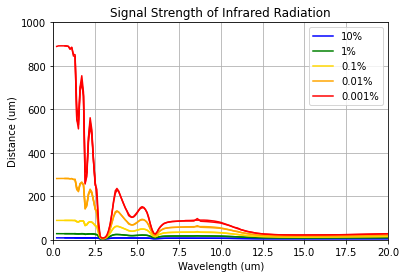

In [24]:
func plot(domain: SIMD2<Float>) {
  // Reset plot
  plt.clf()

  let labels = ["10%", "1%", "0.1%", "0.01%", "0.001%"]
  let colors = ["blue", "green", "gold", "orange", "red"]
  let parameters: [(Bool, ContourMap)] = [
    (true, longMap),
    (false, mediumMap),
    (false, shortMap),
    // (false, iceMap)
  ]

  for (setLabel, map) in parameters {
    for (index, contour) in map.contours.enumerated() {
      let color = colors[index]
      let label = labels[index]

      if setLabel {
        plt.plot(map.wavelengths, contour, color: color, label: label)
      } else {
        plt.plot(map.wavelengths, contour, color: color)
      }
    }
  }

  plt.title("Signal Strength of Infrared Radiation")
  plt.xlabel("Wavelength (um)")
  plt.ylabel("Distance (um)")
  plt.xlim([domain[0], domain[1]])
  plt.ylim([0, 1000])

  plt.grid(true)
  plt.legend()
  plt.show()
}

plot(domain: [0.0, 20.0])

In [ ]:
let mediumWavelengths = mediumMap.wavelengths
print(mediumWavelengths.sorted())
print(mediumMap.contours[0][0])
print(mediumMap.contours[1][0])
print(mediumMap.contours[2][0])
print(mediumMap.contours[3][0])
print(mediumMap.contours[4][0])

print(medium_processed[0])
print(findStrength(radius: 100, absorption: 1492537.4))
print(findStrength(radius: 100, absorption: 40))
print()
print(binarySearch(dataset: medium_processed, λ: 0.2))
print(searchContours(absorption: Array(medium_processed.reversed())[0].y))
print(generateMap2(dataset: medium_processed).contours)

print()
do {
  let contours: [[Float]?] = wavelengths.map { wavelength in
    let absorption = binarySearch(dataset: medium_processed, λ: wavelength)
    guard let absorption = absorption else {
      return nil
    }
    return searchContours(absorption: absorption)
  }
  // print("wavelengths: \(wavelengths)")
  // print("contours: \(contours)")

  do {
    // print("medium dataset:", Array(medium_processed.reversed()))
    let absorption = binarySearch(dataset: medium_processed, λ: 0.2)!
    // print("absorption: \(absorption)")
    // print("contours: \(searchContours(absorption: absorption))")
  }
}

In [21]:
print(findStrength(radius: 5, absorption: 2364963.5))
print(findStrength(radius: 5.1, absorption: 2364963.5))

0.31830925
0.3059489
